#### Đánh giá model GIÁ CUỐI (Hướng 1) — so sánh 3 thuật toán

Nạp lại dự đoán đã lưu từ `train/train_gia.ipynb` (`pred_gia.parquet`), không train lại. Đánh giá:
bảng chỉ số theo thuật toán × test-set, so baseline persistence, biểu đồ dự đoán vs thực tế, phân bố
sai số, sai số theo độ trễ.

In [6]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 220)
BLUE, ORANGE, GREEN = "#0072B2", "#E69F00", "#009E73"

def metrics(y,p):
    y,p=np.asarray(y),np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

PRED = Path("pred_gia.parquet")
assert PRED.exists(), "Chua co file du doan -> chay train/train_gia.ipynb truoc!"
df = pd.read_parquet(PRED)
ALGOS = sorted(df.algo.unique())
thangs = sorted(df.evaluation_month.unique())
print(f"Nap {len(df):,} dong du doan | thuat toan: {ALGOS} | thang: {thangs}")

Nap 2,593,080 dong du doan | thuat toan: ['HistGB', 'LightGBM', 'XGBoost'] | thang: ['2026-01', '2026-02', '2026-03']


**1. Bảng chỉ số — tổng gộp & từng test-set nhỏ theo tháng**

In [7]:
TARGET = "target_shown_price"
rows = []
for algo in ALGOS:
    d = df[df.algo==algo]
    rows.append({"Thuat toan": algo, "Test-set": "TAT CA", "n": len(d), **metrics(d[TARGET], d.pred)})
    for th in thangs:
        dt = d[d.evaluation_month==th]
        rows.append({"Thuat toan": algo, "Test-set": th, "n": len(dt), **metrics(dt[TARGET], dt.pred)})
bang = pd.DataFrame(rows).round(2)
print("TONG GOP:"); display(bang[bang["Test-set"]=="TAT CA"].sort_values("MAE"))
print("\nTUNG TEST-SET NHO THEO THANG:"); display(bang[bang["Test-set"]!="TAT CA"])

TONG GOP:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
8,XGBoost,TAT CA,864360,18806.72,25602.59,0.71,15.34
4,LightGBM,TAT CA,864360,18809.03,25607.87,0.71,15.34
0,HistGB,TAT CA,864360,18834.01,25644.75,0.70,15.36



TUNG TEST-SET NHO THEO THANG:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
1,HistGB,2026-01,315360,18622.75,25327.14,0.71,15.44
2,HistGB,2026-02,234632,18700.76,25422.74,0.71,15.34
3,HistGB,2026-03,314368,19145.39,26121.93,0.70,15.29
5,LightGBM,2026-01,315360,18605.25,25306.00,0.71,15.42
6,LightGBM,2026-02,234632,18670.77,25372.77,0.71,15.32
7,LightGBM,2026-03,314368,19116.64,26079.23,0.70,15.27
9,XGBoost,2026-01,315360,18590.70,25283.05,0.71,15.41
10,XGBoost,2026-02,234632,18676.58,25372.29,0.71,15.33
11,XGBoost,2026-03,314368,19120.54,26087.65,0.70,15.27


**2. So với baseline persistence**

In [8]:
for algo in ALGOS:
    d = df[df.algo==algo]
    per = metrics(d[TARGET], d["persistence_prediction"])["MAE"]
    mae = metrics(d[TARGET], d.pred)["MAE"]
    print(f"{algo:10} MAE model={mae:>8,.0f}  MAE persistence={per:>8,.0f}  cai thien={(1-mae/per)*100:+.1f}%")

HistGB     MAE model=  18,834  MAE persistence=  33,683  cai thien=+44.1%
LightGBM   MAE model=  18,809  MAE persistence=  33,683  cai thien=+44.2%
XGBoost    MAE model=  18,807  MAE persistence=  33,683  cai thien=+44.2%


**3. Biểu đồ — cả 3 thuật toán**

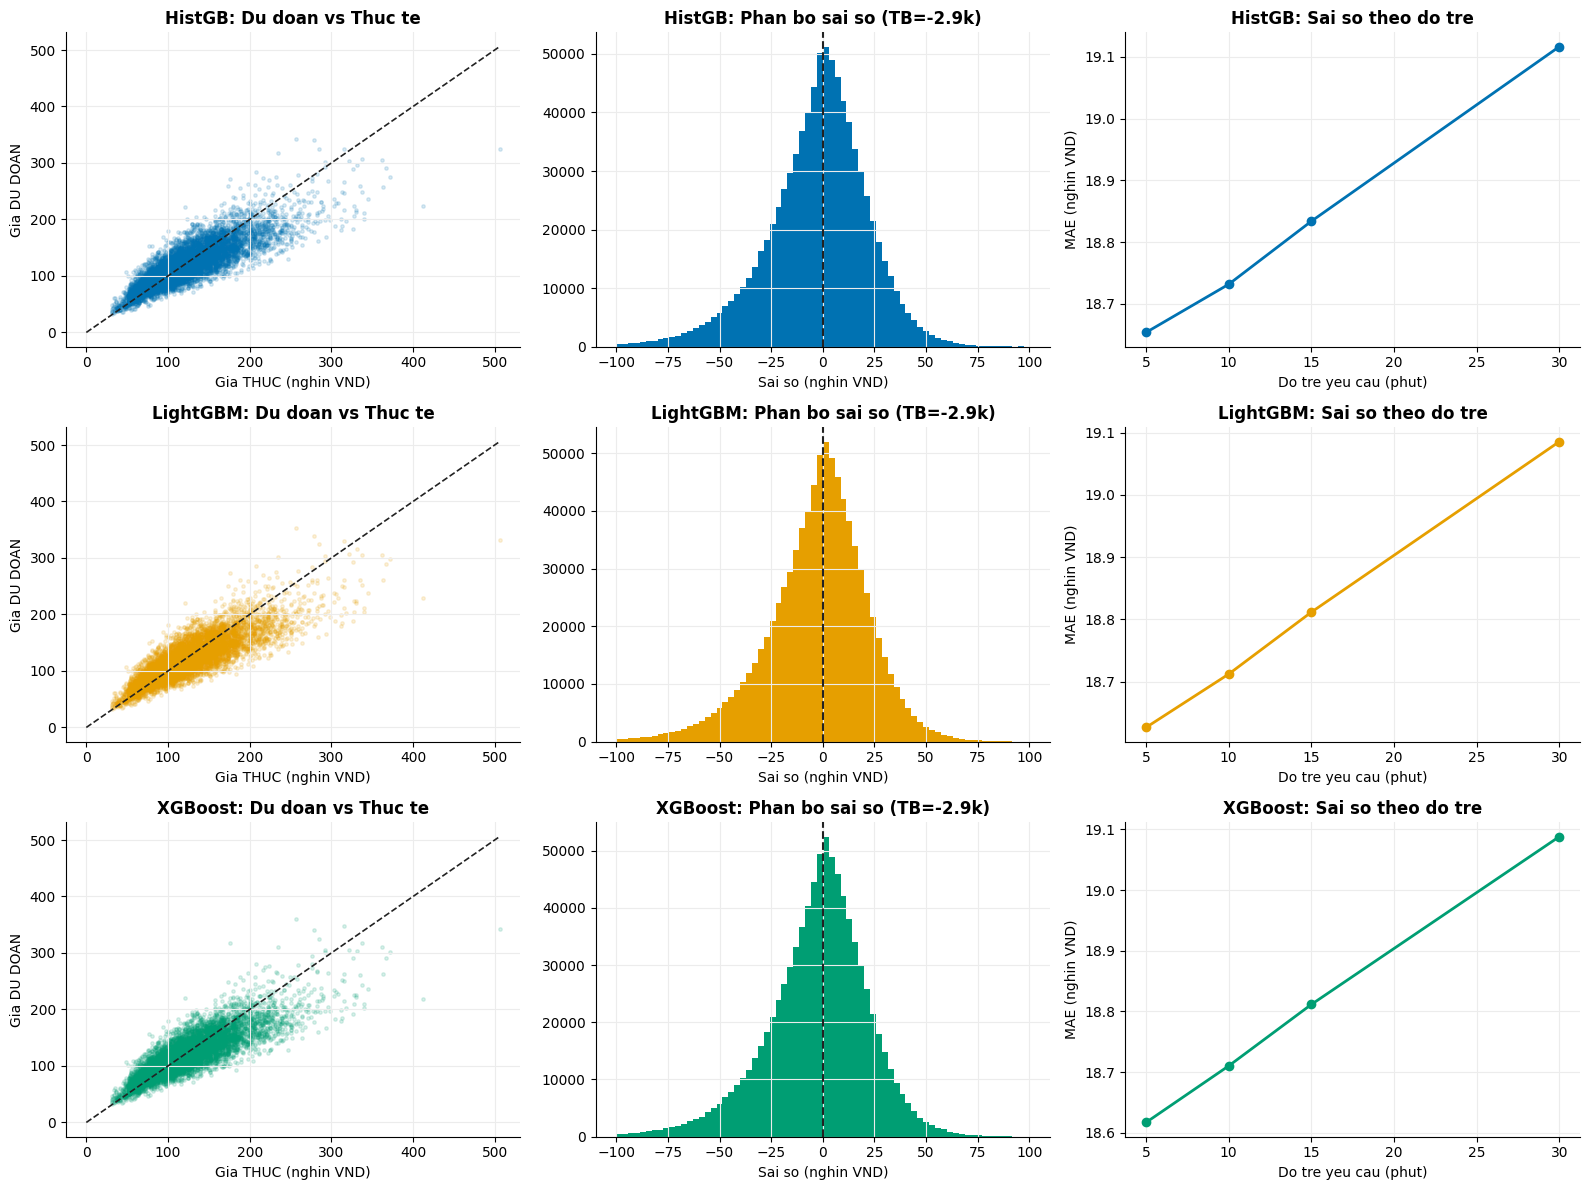

In [9]:
COLORS = dict(zip(ALGOS, [BLUE, ORANGE, GREEN]))
fig, ax = plt.subplots(len(ALGOS), 3, figsize=(16, 4*len(ALGOS)))
if len(ALGOS) == 1: ax = ax[None, :]
for i, algo in enumerate(ALGOS):
    d = df[df.algo==algo]
    c = COLORS[algo]
    s = d.sample(min(8000, len(d)), random_state=0)
    ax[i,0].scatter(s[TARGET]/1000, s.pred/1000, s=6, alpha=.15, color=c)
    lim=[0, s[TARGET].max()/1000]; ax[i,0].plot(lim,lim,"--",color="#222",lw=1.2)
    ax[i,0].set_xlabel("Gia THUC (nghin VND)"); ax[i,0].set_ylabel("Gia DU DOAN")
    ax[i,0].set_title(f"{algo}: Du doan vs Thuc te", fontweight="bold")

    err=(d.pred-d[TARGET])/1000
    ax[i,1].hist(err, bins=70, range=(-100,100), color=c); ax[i,1].axvline(0,color="#222",ls="--")
    ax[i,1].set_xlabel("Sai so (nghin VND)")
    ax[i,1].set_title(f"{algo}: Phan bo sai so (TB={err.mean():+.1f}k)", fontweight="bold")

    lagmae=d.assign(ae=(d.pred-d[TARGET]).abs()).groupby("requested_lag_minutes").ae.mean()/1000
    ax[i,2].plot(lagmae.index, lagmae.values, marker="o", lw=2, color=c)
    ax[i,2].set_xlabel("Do tre yeu cau (phut)"); ax[i,2].set_ylabel("MAE (nghin VND)")
    ax[i,2].set_title(f"{algo}: Sai so theo do tre", fontweight="bold")
plt.tight_layout(); plt.show()

**4. So sánh MAE giữa 3 thuật toán (biểu đồ)**

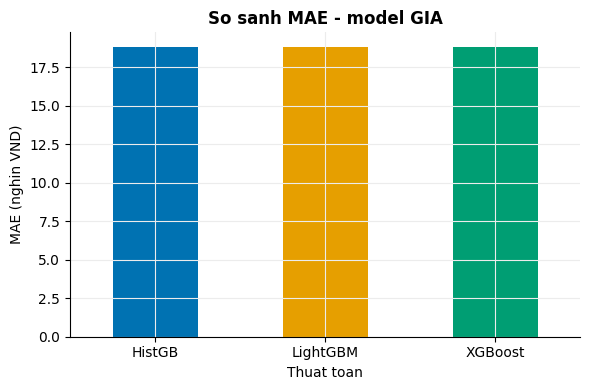

In [10]:
bt = bang[bang["Test-set"]=="TAT CA"].set_index("Thuat toan")["MAE"]/1000
fig, ax = plt.subplots(figsize=(6,4))
bt.plot(kind="bar", ax=ax, color=[BLUE,ORANGE,GREEN][:len(bt)])
ax.set_ylabel("MAE (nghin VND)"); ax.set_title("So sanh MAE - model GIA", fontweight="bold"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()